# Believability Analysis: Under 35 vs Over 35 (24 Headlines)

This notebook uses the 24-headline dataset with only:
- `central` (12 headlines)
- `peripheral` (12 headlines, composed of 6 neutral + 6 peripheral from the original labels)

The stage structure is fully **within-subjects / repeated-measures**: each participant rated headlines across all three stages.
- `latent`: headlines first seen in Stage 1 and rated again later
- `recent`: headlines first seen in Stage 2 and rated again later
- `new`: headlines introduced for the first time in Stage 3

Because the same participants contribute ratings to all condition levels, condition effects and any interactions involving condition are tested with **repeated-measures ANOVA**. Two-level within-participant comparisons (for example, `health` vs `technology`, or `central` vs `peripheral`) are tested with **paired-samples t-tests**.

The plots are organized in two views throughout:
- a separate `Overall` plot
- a direct `Under 35 vs Over 35` comparison plot

Inferential statistics are reported for `Overall`, `Under 35`, and `Over 35` separately.


In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from scipy.stats import ttest_rel, ttest_1samp
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='talk')

# colour palette
BLUE = '#5aa9e6'
ORANGE = '#f4a261'
GREEN = '#7bc96f'

COL_OVERALL = BLUE
COL_U35 = GREEN
COL_O35 = ORANGE
ALPHA = 0.75

AGE_PALETTE = {'Under 35': COL_U35, 'Over 35': COL_O35}
TOPIC_COLORS = {'health': BLUE, 'technology': ORANGE}
CONDITION_COLORS = {'latent': BLUE, 'recent': GREEN, 'new': ORANGE}
CUE_COLORS = {'central': BLUE, 'peripheral': ORANGE}
GROUP_STYLES = {
    'Under 35': {'marker': 'o', 'linestyle': '-'},
    'Over 35': {'marker': 's', 'linestyle': '--'},
}
LEGEND_STYLE = {'fontsize': 9, 'title_fontsize': 10, 'frameon': True}
SIG_STYLE = {'fontsize': 11, 'fontweight': 'bold'}


def place_legend(ax, title=None, loc='upper right', handles=None):
    ax.legend(handles=handles, title=title, loc=loc, **LEGEND_STYLE)


def p_to_stars(p_value):
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


def add_sig_badge(ax, entries, x=0.02, y=0.98, line_gap=0.075):
    if isinstance(entries, dict):
        entries = [entries]
    for idx, entry in enumerate(entries):
        label = entry.get('label', '')
        marker = p_to_stars(entry['p'])
        text = f'{label}: {marker}' if label else marker
        ax.text(
            x,
            y - idx * line_gap,
            text,
            transform=ax.transAxes,
            ha='left',
            va='top',
            color=entry.get('color', 'black'),
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, boxstyle='round,pad=0.2'),
            **SIG_STYLE,
        )


def anova_p(table):
    return table['Pr > F'].iloc[0]


## Load & Prepare Data

In [2]:
DATA_PATH = Path('selected_24_long_dataset.csv')

df_all = pd.read_csv(DATA_PATH)

analysis_cols = [
    'Participation Id', 'Age', 'Gender',
    'Main Source of Information',
    'Education Level (Completed/Current)',
    'Employement',
    'believability_rating', 'text',
    'topic', 'condition', 'cue_type_final',
]

df_all = df_all[analysis_cols].copy()
df_all = df_all.dropna(subset=['Participation Id', 'believability_rating',
                               'text', 'topic', 'condition', 'cue_type_final'])

df_all['Participation Id'] = pd.to_numeric(df_all['Participation Id'], errors='coerce')
df_all['believability_rating'] = pd.to_numeric(df_all['believability_rating'], errors='coerce')
df_all['Age'] = pd.to_numeric(df_all['Age'], errors='coerce')

df_all = df_all.dropna(subset=['Participation Id', 'believability_rating'])
df_all['Participation Id'] = df_all['Participation Id'].astype(int)

for col, cats in [
    ('topic', ['health', 'technology']),
    ('condition', ['latent', 'recent', 'new']),
    ('cue_type_final', ['central', 'peripheral']),
]:
    df_all[col] = pd.Categorical(df_all[col], categories=cats, ordered=True)


def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series[(series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)]


pm_all = df_all.groupby('Participation Id')['believability_rating'].mean()
outliers_all = iqr_outliers(pm_all)
if len(outliers_all):
    print(f'Overall - removing {len(outliers_all)} outlier participant(s): {outliers_all.index.tolist()}')
    df_all = df_all[~df_all['Participation Id'].isin(outliers_all.index)].copy()
    for col, cats in [('topic', ['health', 'technology']), ('condition', ['latent', 'recent', 'new']),
                      ('cue_type_final', ['central', 'peripheral'])]:
        df_all[col] = pd.Categorical(df_all[col], categories=cats, ordered=True)
else:
    print('Overall - no outlier participants detected.')

df_u35 = df_all[df_all['Age'] < 35].copy()
df_o35 = df_all[df_all['Age'] > 35].copy()

pm_u35 = df_u35.groupby('Participation Id')['believability_rating'].mean()
outliers_u35 = iqr_outliers(pm_u35)
if len(outliers_u35):
    print(f'Under 35 - removing {len(outliers_u35)} outlier participant(s): {outliers_u35.index.tolist()}')
    df_u35 = df_u35[~df_u35['Participation Id'].isin(outliers_u35.index)].copy()
    for col, cats in [('topic', ['health', 'technology']), ('condition', ['latent', 'recent', 'new']),
                      ('cue_type_final', ['central', 'peripheral'])]:
        df_u35[col] = pd.Categorical(df_u35[col], categories=cats, ordered=True)
else:
    print('Under 35 - no outlier participants detected.')

pm_o35 = df_o35.groupby('Participation Id')['believability_rating'].mean()
outliers_o35 = iqr_outliers(pm_o35)
if len(outliers_o35):
    print(f'Over 35 - removing {len(outliers_o35)} outlier participant(s): {outliers_o35.index.tolist()}')
    df_o35 = df_o35[~df_o35['Participation Id'].isin(outliers_o35.index)].copy()
    for col, cats in [('topic', ['health', 'technology']), ('condition', ['latent', 'recent', 'new']),
                      ('cue_type_final', ['central', 'peripheral'])]:
        df_o35[col] = pd.Categorical(df_o35[col], categories=cats, ordered=True)
else:
    print('Over 35 - no outlier participants detected.')

df_u35_tagged = df_u35.copy()
df_u35_tagged['Age Group'] = 'Under 35'
df_o35_tagged = df_o35.copy()
df_o35_tagged['Age Group'] = 'Over 35'
age_comparison = pd.concat([df_u35_tagged, df_o35_tagged], ignore_index=True)

print(f'Overall sample : {df_all["Participation Id"].nunique()} participants, {len(df_all)} rows')
print(f'Under 35       : {df_u35["Participation Id"].nunique()} participants, {len(df_u35)} rows')
print(f'Over 35        : {df_o35["Participation Id"].nunique()} participants, {len(df_o35)} rows')
print('Cue levels in analysis:', list(df_all['cue_type_final'].cat.categories))


Overall - no outlier participants detected.
Under 35 - no outlier participants detected.
Over 35 - removing 1 outlier participant(s): [52]
Overall sample : 50 participants, 1200 rows
Under 35       : 37 participants, 888 rows
Over 35        : 12 participants, 288 rows
Cue levels in analysis: ['central', 'peripheral']


In [3]:
# === Inferential statistics results ===
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp, ttest_rel
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests


def paired_dz(x, y):
    diff = np.asarray(x) - np.asarray(y)
    return diff.mean() / diff.std(ddof=1)


def participant_cell_means(data, within_factors):
    return (
        data.groupby(['Participation Id'] + within_factors, observed=False)['believability_rating']
        .mean()
        .reset_index()
        .rename(columns={'Participation Id': 'participant_id', 'believability_rating': 'mean_rating'})
    )


def rm_anova_table(data, within_factors):
    rm_df = participant_cell_means(data, within_factors)
    fit = AnovaRM(rm_df, depvar='mean_rating', subject='participant_id', within=within_factors).fit()
    table = fit.anova_table.reset_index().rename(columns={'index': 'effect'})
    table['partial_eta_sq'] = (table['F Value'] * table['Num DF']) / ((table['F Value'] * table['Num DF']) + table['Den DF'])
    return table


def paired_posthoc_from_pivot(pivot_df, pairs, correction='bonferroni'):
    rows = []
    raw_p_values = []
    for left, right in pairs:
        paired = pivot_df[[left, right]].dropna()
        t_stat, p_value = ttest_rel(paired[left], paired[right])
        rows.append({
            'comparison': f'{left} vs {right}',
            'n': len(paired),
            'mean_left': paired[left].mean(),
            'mean_right': paired[right].mean(),
            't': t_stat,
            'p_raw': p_value,
            'cohens_dz': paired_dz(paired[left], paired[right]),
        })
        raw_p_values.append(p_value)
    result = pd.DataFrame(rows)
    if len(result):
        result['p_adj'] = multipletests(raw_p_values, method=correction)[1]
        result['significant'] = result['p_adj'] < 0.05
    return result


def build_group_results(data):
    n_participants = int(data['Participation Id'].nunique())
    participant_means = data.groupby('Participation Id')['believability_rating'].mean()
    overall_t, overall_p = ttest_1samp(participant_means, popmean=3.0)

    topic_pivot = participant_cell_means(data, ['topic']).pivot(
        index='participant_id', columns='topic', values='mean_rating'
    ).dropna()
    topic_t, topic_p = ttest_rel(topic_pivot['health'], topic_pivot['technology'])

    condition_anova = rm_anova_table(data, ['condition'])
    condition_posthoc = paired_posthoc_from_pivot(
        participant_cell_means(data, ['condition']).pivot(
            index='participant_id', columns='condition', values='mean_rating'
        ),
        [('latent', 'recent'), ('latent', 'new'), ('recent', 'new')]
    )

    cue_pivot = participant_cell_means(data, ['cue_type_final']).pivot(
        index='participant_id', columns='cue_type_final', values='mean_rating'
    ).dropna()
    cue_t, cue_p = ttest_rel(cue_pivot['central'], cue_pivot['peripheral'])

    topic_condition_anova = rm_anova_table(data, ['topic', 'condition'])
    topic_condition_pivot = participant_cell_means(data, ['topic', 'condition']).pivot(
        index='participant_id', columns=['topic', 'condition'], values='mean_rating'
    )
    topic_within_condition_rows = []
    for condition in data['condition'].cat.categories:
        sub = topic_condition_pivot.xs(condition, axis=1, level=1)
        t_stat, p_value = ttest_rel(sub['health'], sub['technology'])
        topic_within_condition_rows.append({
            'condition': condition,
            'health_mean': sub['health'].mean(),
            'technology_mean': sub['technology'].mean(),
            't': t_stat,
            'p_raw': p_value,
            'cohens_dz': paired_dz(sub['health'], sub['technology']),
        })
    topic_within_condition = pd.DataFrame(topic_within_condition_rows)
    topic_within_condition['p_adj'] = multipletests(topic_within_condition['p_raw'], method='bonferroni')[1]
    topic_within_condition['significant'] = topic_within_condition['p_adj'] < 0.05

    condition_within_topic = []
    for topic_name in data['topic'].cat.categories:
        posthoc = paired_posthoc_from_pivot(
            topic_condition_pivot[topic_name],
            [('latent', 'recent'), ('latent', 'new'), ('recent', 'new')]
        )
        posthoc.insert(0, 'topic', topic_name)
        condition_within_topic.append(posthoc)
    condition_within_topic = pd.concat(condition_within_topic, ignore_index=True)

    topic_cue_anova = rm_anova_table(data, ['topic', 'cue_type_final'])
    topic_cue_pivot = participant_cell_means(data, ['topic', 'cue_type_final']).pivot(
        index='participant_id', columns=['topic', 'cue_type_final'], values='mean_rating'
    )
    topic_within_cue_rows = []
    for cue_name in data['cue_type_final'].cat.categories:
        sub = topic_cue_pivot.xs(cue_name, axis=1, level=1)
        t_stat, p_value = ttest_rel(sub['health'], sub['technology'])
        topic_within_cue_rows.append({
            'cue_type': cue_name,
            'health_mean': sub['health'].mean(),
            'technology_mean': sub['technology'].mean(),
            't': t_stat,
            'p_raw': p_value,
            'cohens_dz': paired_dz(sub['health'], sub['technology']),
        })
    topic_within_cue = pd.DataFrame(topic_within_cue_rows)
    topic_within_cue['p_adj'] = multipletests(topic_within_cue['p_raw'], method='bonferroni')[1]
    topic_within_cue['significant'] = topic_within_cue['p_adj'] < 0.05

    cue_within_topic = []
    for topic_name in data['topic'].cat.categories:
        sub = topic_cue_pivot[topic_name]
        t_stat, p_value = ttest_rel(sub['central'], sub['peripheral'])
        cue_within_topic.append({
            'topic': topic_name,
            'central_mean': sub['central'].mean(),
            'peripheral_mean': sub['peripheral'].mean(),
            't': t_stat,
            'p_raw': p_value,
            'cohens_dz': paired_dz(sub['central'], sub['peripheral']),
        })
    cue_within_topic = pd.DataFrame(cue_within_topic)
    cue_within_topic['p_adj'] = multipletests(cue_within_topic['p_raw'], method='bonferroni')[1]
    cue_within_topic['significant'] = cue_within_topic['p_adj'] < 0.05

    condition_cue_anova = rm_anova_table(data, ['condition', 'cue_type_final'])
    condition_cue_pivot = participant_cell_means(data, ['condition', 'cue_type_final']).pivot(
        index='participant_id', columns=['condition', 'cue_type_final'], values='mean_rating'
    )
    cue_within_condition_rows = []
    for condition in data['condition'].cat.categories:
        sub = condition_cue_pivot[condition]
        t_stat, p_value = ttest_rel(sub['central'], sub['peripheral'])
        cue_within_condition_rows.append({
            'condition': condition,
            'central_mean': sub['central'].mean(),
            'peripheral_mean': sub['peripheral'].mean(),
            't': t_stat,
            'p_raw': p_value,
            'cohens_dz': paired_dz(sub['central'], sub['peripheral']),
        })
    cue_within_condition = pd.DataFrame(cue_within_condition_rows)
    cue_within_condition['p_adj'] = multipletests(cue_within_condition['p_raw'], method='bonferroni')[1]
    cue_within_condition['significant'] = cue_within_condition['p_adj'] < 0.05

    condition_within_cue = []
    for cue_name in data['cue_type_final'].cat.categories:
        posthoc = paired_posthoc_from_pivot(
            condition_cue_pivot.xs(cue_name, axis=1, level=1),
            [('latent', 'recent'), ('latent', 'new'), ('recent', 'new')]
        )
        posthoc.insert(0, 'cue_type', cue_name)
        condition_within_cue.append(posthoc)
    condition_within_cue = pd.concat(condition_within_cue, ignore_index=True)

    three_way_anova = rm_anova_table(data, ['topic', 'condition', 'cue_type_final'])
    three_way_pivot = participant_cell_means(data, ['topic', 'condition', 'cue_type_final']).pivot(
        index='participant_id', columns=['topic', 'condition', 'cue_type_final'], values='mean_rating'
    )
    cue_within_topic_condition_rows = []
    for topic_name in data['topic'].cat.categories:
        for condition in data['condition'].cat.categories:
            sub = three_way_pivot[topic_name, condition]
            t_stat, p_value = ttest_rel(sub['central'], sub['peripheral'])
            cue_within_topic_condition_rows.append({
                'topic': topic_name,
                'condition': condition,
                'central_mean': sub['central'].mean(),
                'peripheral_mean': sub['peripheral'].mean(),
                't': t_stat,
                'p_raw': p_value,
                'cohens_dz': paired_dz(sub['central'], sub['peripheral']),
            })
    cue_within_topic_condition = pd.DataFrame(cue_within_topic_condition_rows)
    cue_within_topic_condition['p_adj'] = multipletests(cue_within_topic_condition['p_raw'], method='bonferroni')[1]
    cue_within_topic_condition['significant'] = cue_within_topic_condition['p_adj'] < 0.05

    return {
        'n': n_participants,
        'df_t': n_participants - 1,
        'overall': {
            'mean': participant_means.mean(),
            'sd': participant_means.std(),
            't': overall_t,
            'p': overall_p,
        },
        'topic': {
            'health_mean': topic_pivot['health'].mean(),
            'technology_mean': topic_pivot['technology'].mean(),
            't': topic_t,
            'p': topic_p,
            'dz': paired_dz(topic_pivot['health'], topic_pivot['technology']),
        },
        'condition_anova': condition_anova,
        'condition_posthoc': condition_posthoc,
        'cue': {
            'central_mean': cue_pivot['central'].mean(),
            'peripheral_mean': cue_pivot['peripheral'].mean(),
            't': cue_t,
            'p': cue_p,
            'dz': paired_dz(cue_pivot['central'], cue_pivot['peripheral']),
        },
        'topic_condition_anova': topic_condition_anova,
        'topic_within_condition': topic_within_condition,
        'condition_within_topic': condition_within_topic,
        'topic_cue_anova': topic_cue_anova,
        'topic_within_cue': topic_within_cue,
        'cue_within_topic': cue_within_topic,
        'condition_cue_anova': condition_cue_anova,
        'cue_within_condition': cue_within_condition,
        'condition_within_cue': condition_within_cue,
        'three_way_anova': three_way_anova,
        'cue_within_topic_condition': cue_within_topic_condition,
    }


inferential_results = {
    'Overall': build_group_results(df_all),
    'Under 35': build_group_results(df_u35),
    'Over 35': build_group_results(df_o35),
}


## 1 Rating Distribution

**Note**
The rating-distribution panels are descriptive. The left panel shows the full sample, and the right panel compares the under-35 and over-35 groups on the same axes.

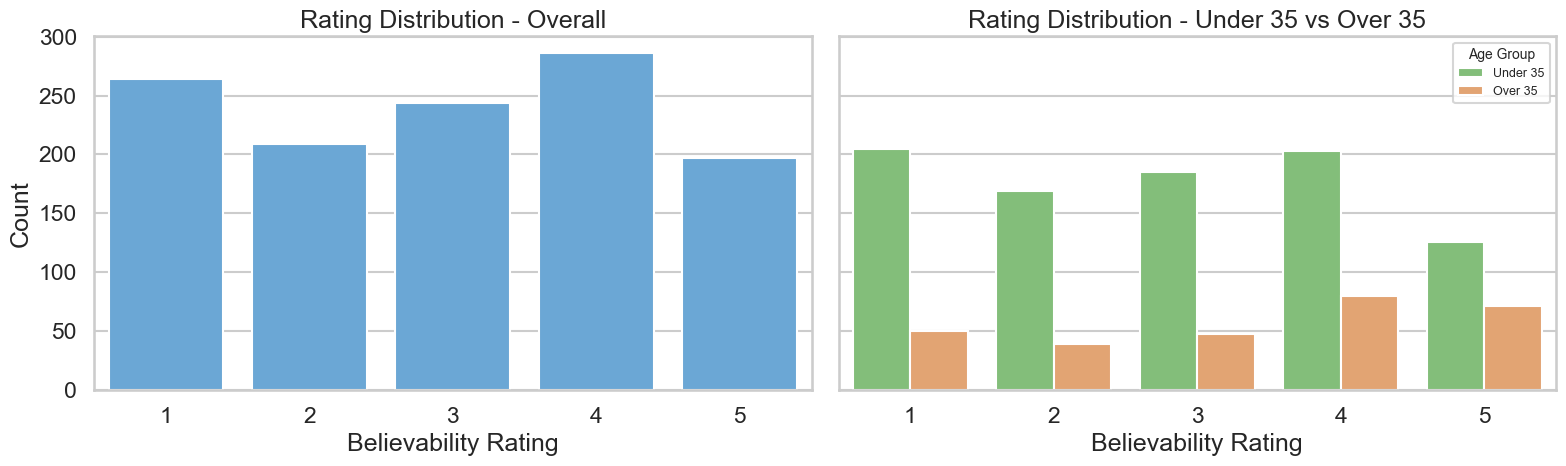

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

sns.countplot(data=df_all, x='believability_rating', color=COL_OVERALL, ax=axes[0])
axes[0].set_title('Rating Distribution - Overall')
axes[0].set_xlabel('Believability Rating')
axes[0].set_ylabel('Count')

sns.countplot(data=age_comparison, x='believability_rating', hue='Age Group',
              palette=AGE_PALETTE, ax=axes[1])
axes[1].set_title('Rating Distribution - Under 35 vs Over 35')
axes[1].set_xlabel('Believability Rating')
axes[1].set_ylabel('Count')
place_legend(axes[1], title='Age Group', loc='upper right')

plt.tight_layout()
plt.show()


## 2 Participant Mean Believability

**Significance testing**
A one-sample t-test compared each participant's mean believability rating against the neutral midpoint of 3.

| Group | Mean | SD | Test | p | Significant |
| --- | --- | --- | --- | --- | --- |
| Overall | 2.953 | 0.620 | t(49) = -0.54 | p = .591 | No |
| Under 35 | 2.860 | 0.655 | t(36) = -1.30 | p = .203 | No |
| Over 35 | 3.288 | 0.353 | t(11) = 2.83 | p = .017 | Yes |

**Sample-size note**
The comparison histogram is now scaled as within-group proportions rather than raw counts, so the two age-group distributions are comparable despite the unequal sample sizes (`Under 35`: n = 37; `Over 35`: n = 12). Descriptively, 35.1% of under-35 participants and 83.3% of over-35 participants had participant-level mean ratings at or above the neutral midpoint of 3.

**Interpretation**
The overall sample and the under-35 group did not differ significantly from neutral, whereas the over-35 group was significantly above the midpoint. The proportion-scaled comparison plot shows the same pattern without letting the larger under-35 sample dominate the visual.


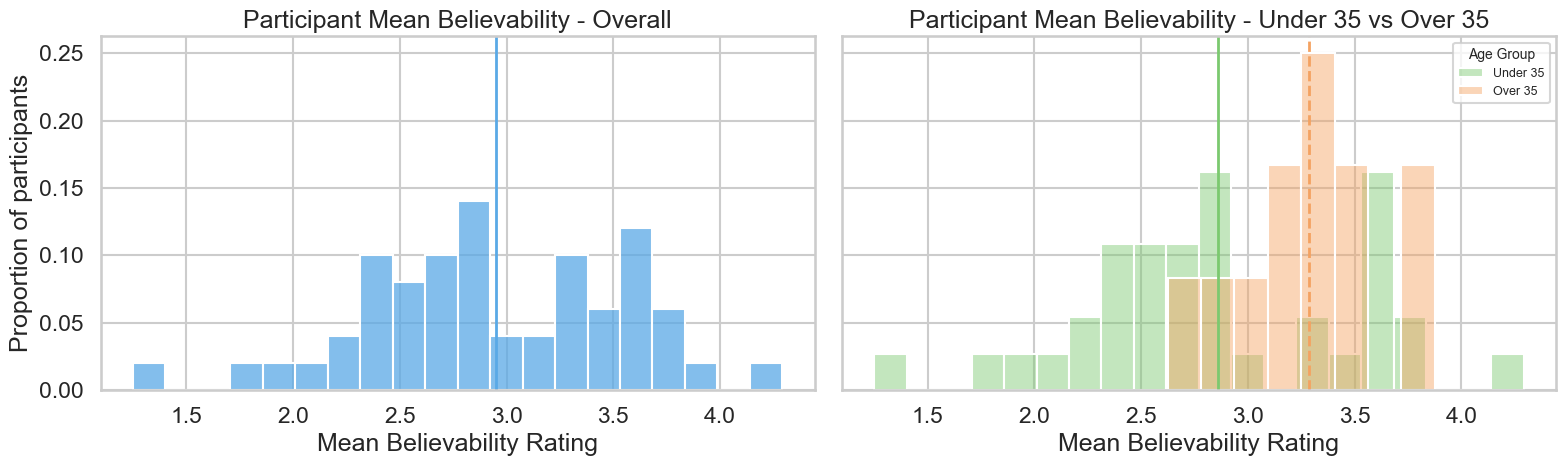

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

overall_means = df_all.groupby('Participation Id')['believability_rating'].mean()
sns.histplot(overall_means, binwidth=0.15, stat='probability', color=COL_OVERALL,
             alpha=ALPHA, ax=axes[0])
axes[0].axvline(overall_means.mean(), color=COL_OVERALL, linestyle='-', linewidth=2)
axes[0].set_title('Participant Mean Believability - Overall')
axes[0].set_xlabel('Mean Believability Rating')
axes[0].set_ylabel('Proportion of participants')

for data, label, color, ls in [
    (df_u35, 'Under 35', COL_U35, '-'),
    (df_o35, 'Over 35', COL_O35, '--'),
]:
    pmeans = data.groupby('Participation Id')['believability_rating'].mean()
    sns.histplot(pmeans, binwidth=0.15, stat='probability', common_norm=False,
                 color=color, alpha=0.45, label=label, ax=axes[1])
    axes[1].axvline(pmeans.mean(), color=color, linestyle=ls, linewidth=2)

axes[1].set_title('Participant Mean Believability - Under 35 vs Over 35')
axes[1].set_xlabel('Mean Believability Rating')
axes[1].set_ylabel('Proportion of participants')
place_legend(axes[1], title='Age Group', loc='upper right')

plt.tight_layout()
plt.show()


## 3 Mean Rating by Topic

**Significance testing**
A within-participant paired-samples t-test compared participant-level mean ratings for health versus technology headlines.

| Group | Health mean | Technology mean | Test | p | Cohen's dz | Significant |
| --- | --- | --- | --- | --- | --- | --- |
| Overall | 3.092 | 2.813 | t(49) = 3.42 | p = .001 | 0.484 | Yes |
| Under 35 | 3.009 | 2.712 | t(36) = 3.07 | p = .004 | 0.505 | Yes |
| Over 35 | 3.410 | 3.167 | t(11) = 1.47 | p = .171 | 0.423 | No |

**Interpretation**
Health headlines were rated significantly more believable than technology headlines in the overall sample and in the under-35 group. The same within-participant topic difference was not significant in the over-35 group.


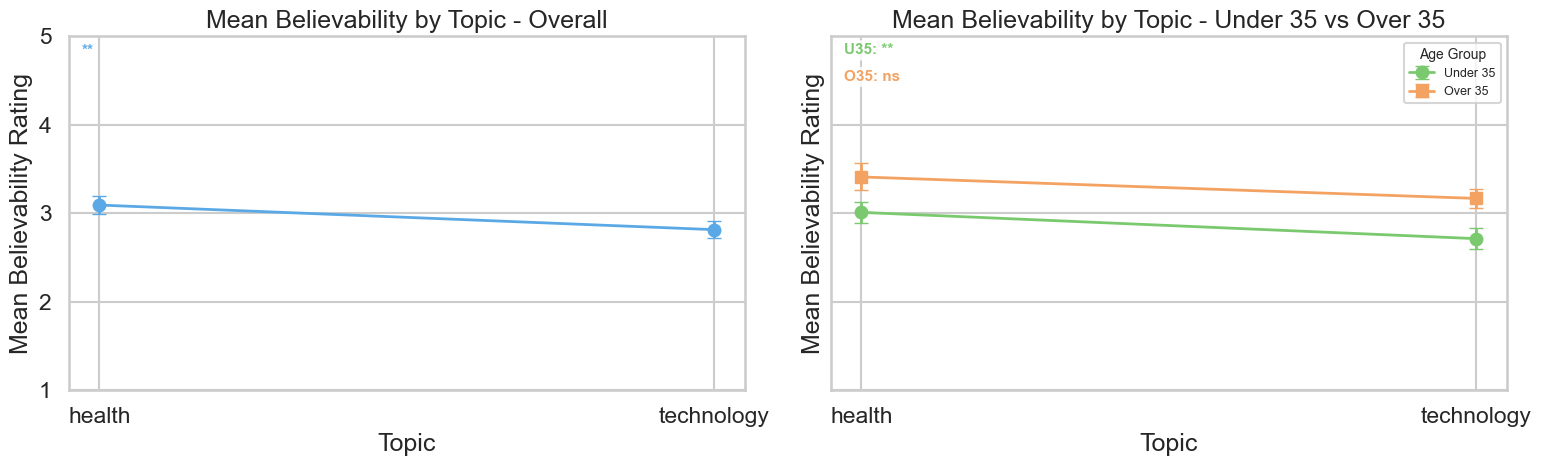

In [6]:
def cell_means(data, factors):
    return (
        data.groupby(['Participation Id'] + factors, observed=False)['believability_rating']
        .mean().reset_index()
        .rename(columns={'Participation Id': 'participant_id',
                         'believability_rating': 'mean_rating'})
    )


def mean_sem(data, factors):
    cells = cell_means(data, factors)
    return cells.groupby(factors, observed=False)['mean_rating'].agg(mean='mean', sem='sem').reset_index()


fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

s = mean_sem(df_all, ['topic'])
axes[0].errorbar(s['topic'].astype(str), s['mean'],
                 yerr=s['sem'], fmt='o-',
                 color=COL_OVERALL, capsize=5, linewidth=2)
axes[0].set_title('Mean Believability by Topic - Overall')
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Mean Believability Rating')
axes[0].set_ylim(1, 5)
add_sig_badge(axes[0], {'p': inferential_results['Overall']['topic']['p'], 'color': COL_OVERALL})

for data, label, color, marker in [
    (df_u35, 'Under 35', COL_U35, 'o'),
    (df_o35, 'Over 35', COL_O35, 's'),
]:
    s = mean_sem(data, ['topic'])
    axes[1].errorbar(s['topic'].astype(str), s['mean'],
                     yerr=s['sem'], fmt=f'{marker}-',
                     color=color, capsize=5, label=label, linewidth=2)

axes[1].set_title('Mean Believability by Topic - Under 35 vs Over 35')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Mean Believability Rating')
axes[1].set_ylim(1, 5)
place_legend(axes[1], title='Age Group', loc='upper right')
add_sig_badge(axes[1], [
    {'label': 'U35', 'p': inferential_results['Under 35']['topic']['p'], 'color': COL_U35},
    {'label': 'O35', 'p': inferential_results['Over 35']['topic']['p'], 'color': COL_O35},
])

plt.tight_layout()
plt.show()


## 4 Mean Rating by Condition

**Significance testing**
A one-factor repeated-measures ANOVA tested the within-participant condition effect (`latent`, `recent`, `new`), followed by Bonferroni-corrected paired-samples t-tests.

**ANOVA**

| Group | Effect | df | p | eta_p^2 | Significant |
| --- | --- | --- | --- | --- | --- |
| Overall | F(2, 98) = 43.39 | 2, 98 | p < .001 | 0.470 | Yes |
| Under 35 | F(2, 72) = 32.04 | 2, 72 | p < .001 | 0.471 | Yes |
| Over 35 | F(2, 22) = 14.65 | 2, 22 | p < .001 | 0.571 | Yes |

**Post-hoc pairwise comparisons (Bonferroni-corrected)**

| Group | Comparison | Mean (left) | Mean (right) | Test | p (adj) | Significant |
| --- | --- | --- | --- | --- | --- | --- |
| Overall | latent vs recent | 3.072 | 3.171 | t(49) = -1.44 | p = .468 | No |
| Overall | latent vs new | 3.072 | 2.534 | t(49) = 7.21 | p < .001 | Yes |
| Overall | recent vs new | 3.171 | 2.534 | t(49) = 8.23 | p < .001 | Yes |
| Under 35 | latent vs recent | 3.017 | 3.021 | t(36) = -0.05 | p = 1.000 | No |
| Under 35 | latent vs new | 3.017 | 2.475 | t(36) = 6.72 | p < .001 | Yes |
| Under 35 | recent vs new | 3.021 | 2.475 | t(36) = 7.00 | p < .001 | Yes |
| Over 35 | latent vs recent | 3.302 | 3.694 | t(11) = -3.00 | p = .036 | Yes |
| Over 35 | latent vs new | 3.302 | 2.750 | t(11) = 2.87 | p = .046 | Yes |
| Over 35 | recent vs new | 3.694 | 2.750 | t(11) = 4.84 | p = .002 | Yes |

**Interpretation**
Condition was significant in all three groups. In the overall and under-35 samples, new headlines were less believable than latent and recent headlines, while latent and recent did not differ. In the over-35 group, all three within-participant condition contrasts were significant, with recent highest and new lowest.


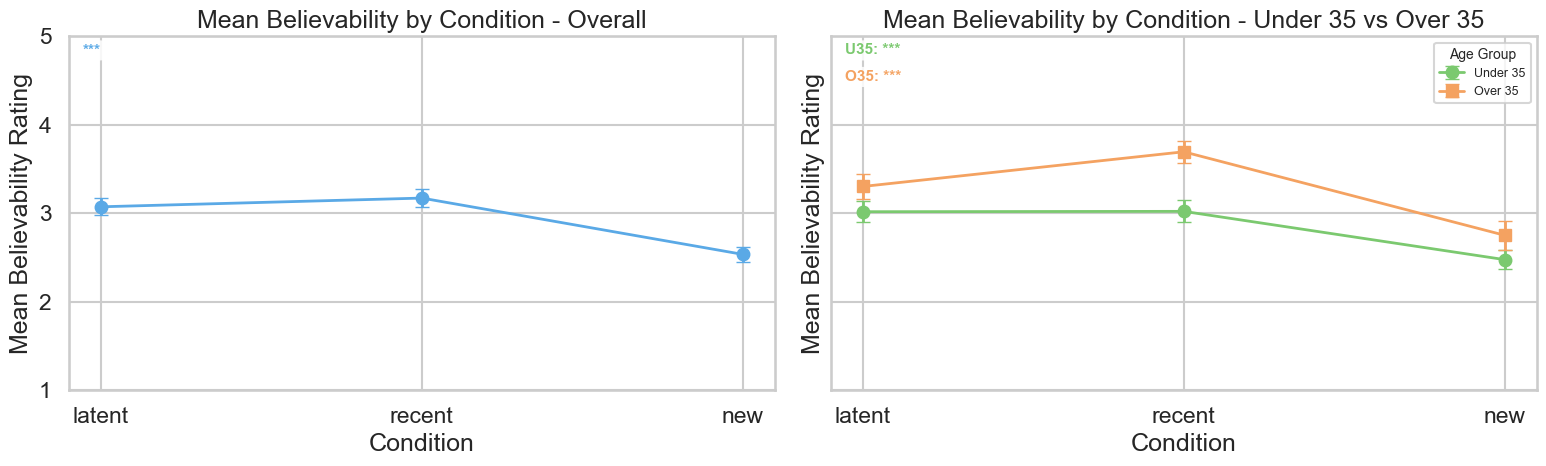

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

s = mean_sem(df_all, ['condition'])
axes[0].errorbar(s['condition'].astype(str), s['mean'],
                 yerr=s['sem'], fmt='o-',
                 color=COL_OVERALL, capsize=5, linewidth=2)
axes[0].set_title('Mean Believability by Condition - Overall')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Mean Believability Rating')
axes[0].set_ylim(1, 5)
add_sig_badge(axes[0], {'p': anova_p(inferential_results['Overall']['condition_anova']), 'color': COL_OVERALL})

for data, label, color, marker in [
    (df_u35, 'Under 35', COL_U35, 'o'),
    (df_o35, 'Over 35', COL_O35, 's'),
]:
    s = mean_sem(data, ['condition'])
    axes[1].errorbar(s['condition'].astype(str), s['mean'],
                     yerr=s['sem'], fmt=f'{marker}-',
                     color=color, capsize=5, label=label, linewidth=2)

axes[1].set_title('Mean Believability by Condition - Under 35 vs Over 35')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Mean Believability Rating')
axes[1].set_ylim(1, 5)
place_legend(axes[1], title='Age Group', loc='upper right')
add_sig_badge(axes[1], [
    {'label': 'U35', 'p': anova_p(inferential_results['Under 35']['condition_anova']), 'color': COL_U35},
    {'label': 'O35', 'p': anova_p(inferential_results['Over 35']['condition_anova']), 'color': COL_O35},
])

plt.tight_layout()
plt.show()


## 5 Mean Rating by Cue Type

**Significance testing**
A within-participant paired-samples t-test compared central versus peripheral cue headlines.

| Group | Central mean | Peripheral mean | Test | p | Cohen's dz | Significant |
| --- | --- | --- | --- | --- | --- | --- |
| Overall | 3.042 | 2.863 | t(49) = 2.19 | p = .033 | 0.309 | Yes |
| Under 35 | 2.948 | 2.773 | t(36) = 1.94 | p = .060 | 0.319 | No |
| Over 35 | 3.396 | 3.181 | t(11) = 1.08 | p = .304 | 0.311 | No |

**Interpretation**
The cue-type main effect was significant only in the overall sample. It did not reach significance within the under-35 or over-35 groups separately.


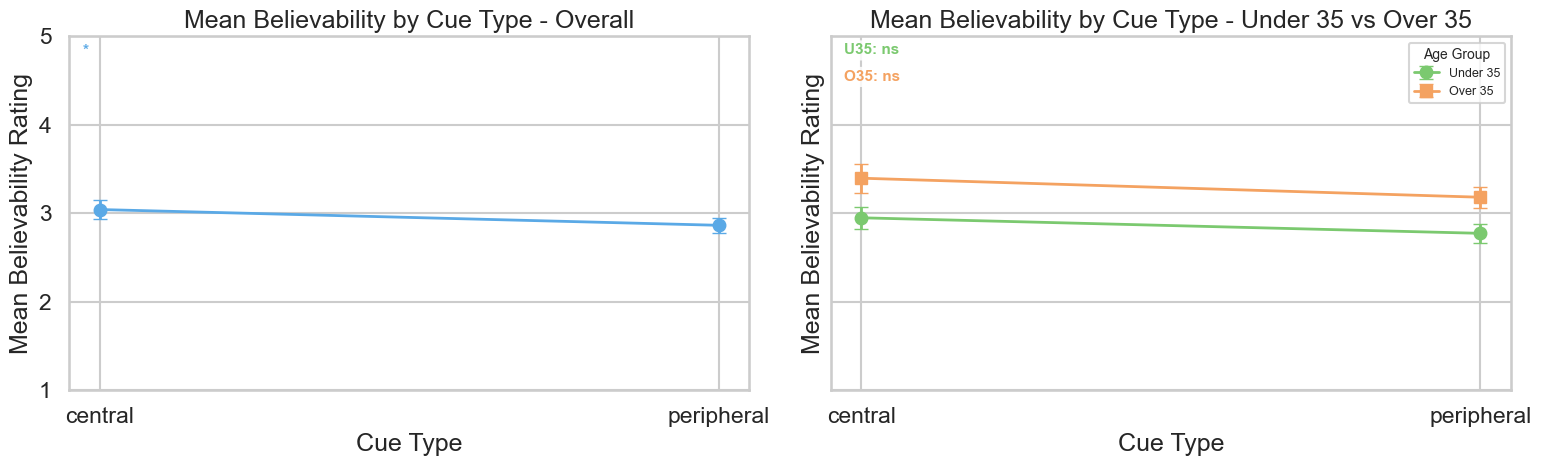

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

s = mean_sem(df_all, ['cue_type_final'])
axes[0].errorbar(s['cue_type_final'].astype(str), s['mean'],
                 yerr=s['sem'], fmt='o-',
                 color=COL_OVERALL, capsize=5, linewidth=2)
axes[0].set_title('Mean Believability by Cue Type - Overall')
axes[0].set_xlabel('Cue Type')
axes[0].set_ylabel('Mean Believability Rating')
axes[0].set_ylim(1, 5)
add_sig_badge(axes[0], {'p': inferential_results['Overall']['cue']['p'], 'color': COL_OVERALL})

for data, label, color, marker in [
    (df_u35, 'Under 35', COL_U35, 'o'),
    (df_o35, 'Over 35', COL_O35, 's'),
]:
    s = mean_sem(data, ['cue_type_final'])
    axes[1].errorbar(s['cue_type_final'].astype(str), s['mean'],
                     yerr=s['sem'], fmt=f'{marker}-',
                     color=color, capsize=5, label=label, linewidth=2)

axes[1].set_title('Mean Believability by Cue Type - Under 35 vs Over 35')
axes[1].set_xlabel('Cue Type')
axes[1].set_ylabel('Mean Believability Rating')
axes[1].set_ylim(1, 5)
place_legend(axes[1], title='Age Group', loc='upper right')
add_sig_badge(axes[1], [
    {'label': 'U35', 'p': inferential_results['Under 35']['cue']['p'], 'color': COL_U35},
    {'label': 'O35', 'p': inferential_results['Over 35']['cue']['p'], 'color': COL_O35},
])

plt.tight_layout()
plt.show()


## 6 Topic x Condition Interaction

**Significance testing**
A repeated-measures ANOVA tested the within-participant Topic x Condition interaction. Because the interaction was significant in all three groups, Bonferroni-corrected simple-effects tests were added.

**Interaction ANOVA**

| Group | Interaction | df | p | eta_p^2 | Significant |
| --- | --- | --- | --- | --- | --- |
| Overall | F(2, 98) = 27.79 | 2, 98 | p < .001 | 0.362 | Yes |
| Under 35 | F(2, 72) = 18.65 | 2, 72 | p < .001 | 0.341 | Yes |
| Over 35 | F(2, 22) = 10.62 | 2, 22 | p < .001 | 0.491 | Yes |

**Topic simple effects within each condition (Bonferroni-corrected)**

| Group | Condition | Health mean | Technology mean | Test | p (adj) | Significant |
| --- | --- | --- | --- | --- | --- | --- |
| Overall | latent | 2.940 | 3.205 | t(49) = -2.07 | p = .131 | No |
| Overall | recent | 3.508 | 2.750 | t(49) = 7.15 | p < .001 | Yes |
| Overall | new | 2.600 | 2.485 | t(49) = 1.04 | p = .917 | No |
| Under 35 | latent | 2.926 | 3.108 | t(36) = -1.15 | p = .774 | No |
| Under 35 | recent | 3.357 | 2.601 | t(36) = 6.33 | p < .001 | Yes |
| Under 35 | new | 2.541 | 2.426 | t(36) = 0.96 | p = 1.000 | No |
| Over 35 | latent | 3.021 | 3.583 | t(11) = -2.89 | p = .044 | Yes |
| Over 35 | recent | 4.067 | 3.229 | t(11) = 3.45 | p = .016 | Yes |
| Over 35 | new | 2.833 | 2.688 | t(11) = 0.51 | p = 1.000 | No |

**Condition pairwise comparisons within each topic (Bonferroni-corrected)**

| Group | Topic | Comparison | Mean (left) | Mean (right) | Test | p (adj) | Significant |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Overall | health | latent vs recent | 2.940 | 3.508 | t(49) = -5.91 | p < .001 | Yes |
| Overall | health | latent vs new | 2.940 | 2.600 | t(49) = 3.02 | p = .012 | Yes |
| Overall | health | recent vs new | 3.508 | 2.600 | t(49) = 8.17 | p < .001 | Yes |
| Overall | technology | latent vs recent | 3.205 | 2.750 | t(49) = 4.42 | p < .001 | Yes |
| Overall | technology | latent vs new | 3.205 | 2.485 | t(49) = 7.38 | p < .001 | Yes |
| Overall | technology | recent vs new | 2.750 | 2.485 | t(49) = 2.83 | p = .020 | Yes |
| Under 35 | health | latent vs recent | 2.926 | 3.357 | t(36) = -4.25 | p < .001 | Yes |
| Under 35 | health | latent vs new | 2.926 | 2.541 | t(36) = 3.38 | p = .005 | Yes |
| Under 35 | health | recent vs new | 3.357 | 2.541 | t(36) = 7.25 | p < .001 | Yes |
| Under 35 | technology | latent vs recent | 3.108 | 2.601 | t(36) = 4.12 | p < .001 | Yes |
| Under 35 | technology | latent vs new | 3.108 | 2.426 | t(36) = 5.96 | p < .001 | Yes |
| Under 35 | technology | recent vs new | 2.601 | 2.426 | t(36) = 1.62 | p = .340 | No |
| Over 35 | health | latent vs recent | 3.021 | 4.067 | t(11) = -5.35 | p < .001 | Yes |
| Over 35 | health | latent vs new | 3.021 | 2.833 | t(11) = 0.59 | p = 1.000 | No |
| Over 35 | health | recent vs new | 4.067 | 2.833 | t(11) = 4.18 | p = .005 | Yes |
| Over 35 | technology | latent vs recent | 3.583 | 3.229 | t(11) = 1.81 | p = .293 | No |
| Over 35 | technology | latent vs new | 3.583 | 2.688 | t(11) = 4.63 | p = .002 | Yes |
| Over 35 | technology | recent vs new | 3.229 | 2.688 | t(11) = 2.90 | p = .043 | Yes |

**Interpretation**
The Topic x Condition interaction was robust across overall, under-35, and over-35 analyses. The recent condition consistently drove the strongest topic separation, though the over-35 group also showed a reversed topic effect in the latent condition.

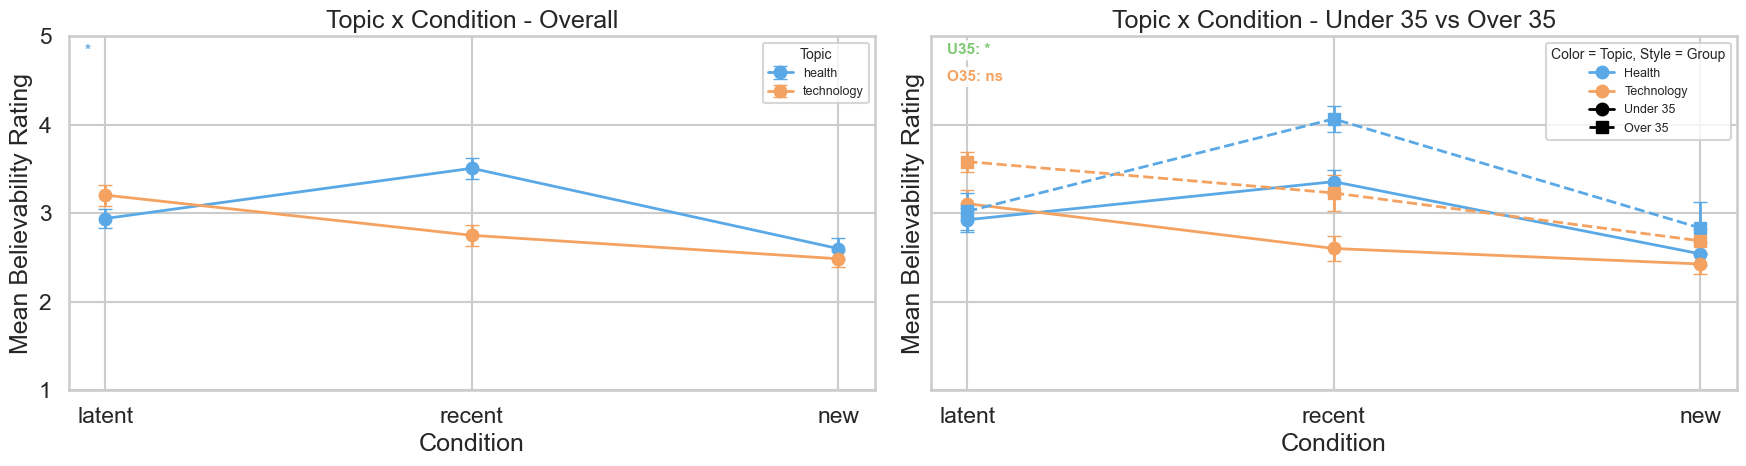

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

s = mean_sem(df_all, ['topic', 'condition'])
for topic in s['topic'].cat.categories:
    sub = s[s['topic'] == topic]
    axes[0].errorbar(sub['condition'].astype(str), sub['mean'],
                     yerr=sub['sem'], marker='o', linestyle='-',
                     color=TOPIC_COLORS[str(topic)], capsize=5,
                     label=str(topic), linewidth=2)

axes[0].set_title('Topic x Condition - Overall')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Mean Believability Rating')
axes[0].set_ylim(1, 5)
place_legend(axes[0], title='Topic', loc='upper right')
add_sig_badge(axes[0], {'p': anova_p(inferential_results['Overall']['topic_condition_anova']), 'color': COL_OVERALL})

for data, group_label in [(df_u35, 'Under 35'), (df_o35, 'Over 35')]:
    s = mean_sem(data, ['topic', 'condition'])
    for topic in s['topic'].cat.categories:
        sub = s[s['topic'] == topic]
        style = GROUP_STYLES[group_label]
        axes[1].errorbar(sub['condition'].astype(str), sub['mean'],
                         yerr=sub['sem'], marker=style['marker'], linestyle=style['linestyle'],
                         color=TOPIC_COLORS[str(topic)], capsize=5, linewidth=2)

topic_handles = [Line2D([0], [0], color=color, marker='o', linestyle='-', linewidth=2, label=topic.title())
                 for topic, color in TOPIC_COLORS.items()]
group_handles = [Line2D([0], [0], color='black', marker=style['marker'], linestyle=style['linestyle'],
                        linewidth=2, label=label)
                 for label, style in GROUP_STYLES.items()]

axes[1].set_title('Topic x Condition - Under 35 vs Over 35')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Mean Believability Rating')
axes[1].set_ylim(1, 5)
place_legend(axes[1], handles=topic_handles + group_handles,
             title='Color = Topic, Style = Group', loc='upper right')
add_sig_badge(axes[1], [
    {'label': 'U35', 'p': anova_p(inferential_results['Under 35']['topic_condition_anova']), 'color': COL_U35},
    {'label': 'O35', 'p': anova_p(inferential_results['Over 35']['topic_condition_anova']), 'color': COL_O35},
])

plt.tight_layout()
plt.show()


## 7 Topic x Cue Type Interaction

**Significance testing**
A repeated-measures ANOVA tested the within-participant Topic x Cue interaction. Because the interaction was significant only in the under-35 group, Bonferroni-corrected simple-effects tests are reported for that group only.

| Group | Interaction | df | p | eta_p^2 | Significant |
| --- | --- | --- | --- | --- | --- |
| Overall | F(1, 49) = 3.83 | 1, 49 | p = .056 | 0.073 | No |
| Under 35 | F(1, 36) = 5.10 | 1, 36 | p = .030 | 0.124 | Yes |
| Over 35 | F(1, 11) = 0.11 | 1, 11 | p = .746 | 0.010 | No |

**Topic simple effects within each cue type (Under 35 only; Bonferroni-corrected)**

| Cue type | Health mean | Technology mean | Test | p (adj) | Significant |
| --- | --- | --- | --- | --- | --- |
| Central | 3.018 | 2.878 | t(36) = 1.25 | p = .438 | No |
| Peripheral | 3.000 | 2.545 | t(36) = 3.59 | p = .002 | Yes |

**Cue simple effects within each topic (Under 35 only; Bonferroni-corrected)**

| Topic | Central mean | Peripheral mean | Test | p (adj) | Significant |
| --- | --- | --- | --- | --- | --- |
| Health | 3.018 | 3.000 | t(36) = 0.18 | p = 1.000 | No |
| Technology | 2.878 | 2.545 | t(36) = 2.62 | p = .025 | Yes |

**Interpretation**
The Topic x Cue interaction is best interpreted as an under-35 effect. Within that group, the topic difference appears only for peripheral headlines, and the cue-type difference appears only for technology headlines, where peripheral cues reduce believability relative to central cues. The overall sample shows only a near-significant trend, and the over-35 group shows no reliable Topic x Cue interaction.


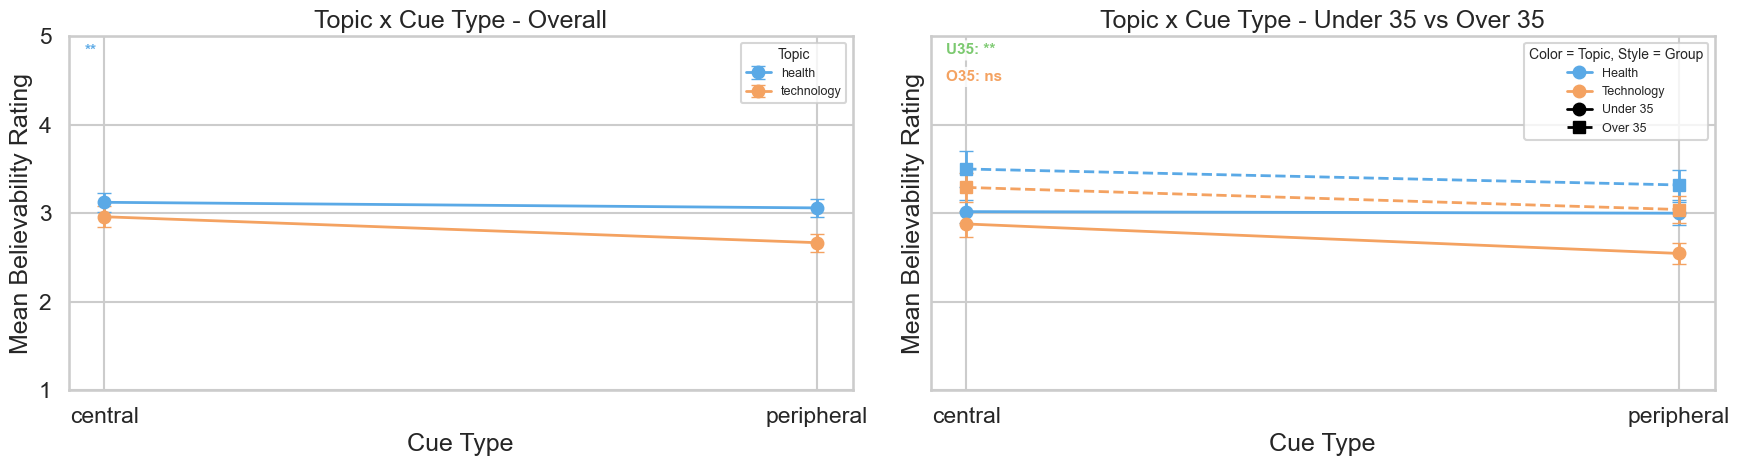

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

s = mean_sem(df_all, ['topic', 'cue_type_final'])
for topic in s['topic'].cat.categories:
    sub = s[s['topic'] == topic]
    axes[0].errorbar(sub['cue_type_final'].astype(str), sub['mean'],
                     yerr=sub['sem'], marker='o', linestyle='-',
                     color=TOPIC_COLORS[str(topic)], capsize=5,
                     label=str(topic), linewidth=2)

axes[0].set_title('Topic x Cue Type - Overall')
axes[0].set_xlabel('Cue Type')
axes[0].set_ylabel('Mean Believability Rating')
axes[0].set_ylim(1, 5)
place_legend(axes[0], title='Topic', loc='upper right')
add_sig_badge(axes[0], {'p': anova_p(inferential_results['Overall']['topic_cue_anova']), 'color': COL_OVERALL})

for data, group_label in [(df_u35, 'Under 35'), (df_o35, 'Over 35')]:
    s = mean_sem(data, ['topic', 'cue_type_final'])
    for topic in s['topic'].cat.categories:
        sub = s[s['topic'] == topic]
        style = GROUP_STYLES[group_label]
        axes[1].errorbar(sub['cue_type_final'].astype(str), sub['mean'],
                         yerr=sub['sem'], marker=style['marker'], linestyle=style['linestyle'],
                         color=TOPIC_COLORS[str(topic)], capsize=5, linewidth=2)

topic_handles = [Line2D([0], [0], color=color, marker='o', linestyle='-', linewidth=2, label=topic.title())
                 for topic, color in TOPIC_COLORS.items()]
group_handles = [Line2D([0], [0], color='black', marker=style['marker'], linestyle=style['linestyle'],
                        linewidth=2, label=label)
                 for label, style in GROUP_STYLES.items()]

axes[1].set_title('Topic x Cue Type - Under 35 vs Over 35')
axes[1].set_xlabel('Cue Type')
axes[1].set_ylabel('Mean Believability Rating')
axes[1].set_ylim(1, 5)
place_legend(axes[1], handles=topic_handles + group_handles,
             title='Color = Topic, Style = Group', loc='upper right')
add_sig_badge(axes[1], [
    {'label': 'U35', 'p': anova_p(inferential_results['Under 35']['topic_cue_anova']), 'color': COL_U35},
    {'label': 'O35', 'p': anova_p(inferential_results['Over 35']['topic_cue_anova']), 'color': COL_O35},
])

plt.tight_layout()
plt.show()


## 8 Condition x Cue Type Interaction

**Significance testing**
A repeated-measures ANOVA tested the within-participant Condition x Cue interaction. Because the interaction was significant in all three groups, Bonferroni-corrected simple-effects tests were added.

**Interaction ANOVA**

| Group | Interaction | df | p | eta_p^2 | Significant |
| --- | --- | --- | --- | --- | --- |
| Overall | F(2, 98) = 14.08 | 2, 98 | p < .001 | 0.223 | Yes |
| Under 35 | F(2, 72) = 8.82 | 2, 72 | p < .001 | 0.197 | Yes |
| Over 35 | F(2, 22) = 7.74 | 2, 22 | p = .003 | 0.413 | Yes |

**Cue simple effects within each condition (Bonferroni-corrected)**

| Group | Condition | Central mean | Peripheral mean | Test | p (adj) | Significant |
| --- | --- | --- | --- | --- | --- | --- |
| Overall | latent | 2.980 | 3.165 | t(49) = -1.43 | p = .473 | No |
| Overall | recent | 3.415 | 2.976 | t(49) = 4.67 | p < .001 | Yes |
| Overall | new | 2.730 | 2.273 | t(49) = 3.90 | p < .001 | Yes |
| Under 35 | latent | 2.932 | 3.101 | t(36) = -1.13 | p = .804 | No |
| Under 35 | recent | 3.284 | 2.811 | t(36) = 4.53 | p < .001 | Yes |
| Under 35 | new | 2.628 | 2.270 | t(36) = 2.59 | p = .041 | Yes |
| Over 35 | latent | 3.208 | 3.396 | t(11) = -0.67 | p = 1.000 | No |
| Over 35 | recent | 3.875 | 3.550 | t(11) = 1.42 | p = .553 | No |
| Over 35 | new | 3.104 | 2.278 | t(11) = 4.07 | p = .006 | Yes |

**Condition pairwise comparisons within each cue type (Bonferroni-corrected)**

| Group | Cue type | Comparison | Mean (left) | Mean (right) | Test | p (adj) | Significant |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Overall | central | latent vs recent | 2.980 | 3.415 | t(49) = -4.35 | p < .001 | Yes |
| Overall | central | latent vs new | 2.980 | 2.730 | t(49) = 2.69 | p = .029 | Yes |
| Overall | central | recent vs new | 3.415 | 2.730 | t(49) = 8.48 | p < .001 | Yes |
| Overall | peripheral | latent vs recent | 3.165 | 2.976 | t(49) = 2.17 | p = .104 | No |
| Overall | peripheral | latent vs new | 3.165 | 2.273 | t(49) = 7.55 | p < .001 | Yes |
| Overall | peripheral | recent vs new | 2.976 | 2.273 | t(49) = 5.67 | p < .001 | Yes |
| Under 35 | central | latent vs recent | 2.932 | 3.284 | t(36) = -3.06 | p = .012 | Yes |
| Under 35 | central | latent vs new | 2.932 | 2.628 | t(36) = 2.76 | p = .027 | Yes |
| Under 35 | central | recent vs new | 3.284 | 2.628 | t(36) = 7.79 | p < .001 | Yes |
| Under 35 | peripheral | latent vs recent | 3.101 | 2.811 | t(36) = 2.88 | p = .020 | Yes |
| Under 35 | peripheral | latent vs new | 3.101 | 2.270 | t(36) = 6.38 | p < .001 | Yes |
| Under 35 | peripheral | recent vs new | 2.811 | 2.270 | t(36) = 3.84 | p = .001 | Yes |
| Over 35 | central | latent vs recent | 3.208 | 3.875 | t(11) = -3.15 | p = .028 | Yes |
| Over 35 | central | latent vs new | 3.208 | 3.104 | t(11) = 0.56 | p = 1.000 | No |
| Over 35 | central | recent vs new | 3.875 | 3.104 | t(11) = 3.49 | p = .015 | Yes |
| Over 35 | peripheral | latent vs recent | 3.396 | 3.550 | t(11) = -1.01 | p = 1.000 | No |
| Over 35 | peripheral | latent vs new | 3.396 | 2.278 | t(11) = 3.94 | p = .007 | Yes |
| Over 35 | peripheral | recent vs new | 3.550 | 2.278 | t(11) = 6.13 | p < .001 | Yes |

**Interpretation**
The Condition x Cue interaction was significant overall and within both age groups. The clearest shared pattern is that cue differences are strongest for newer misinformation, especially in the over-35 group.

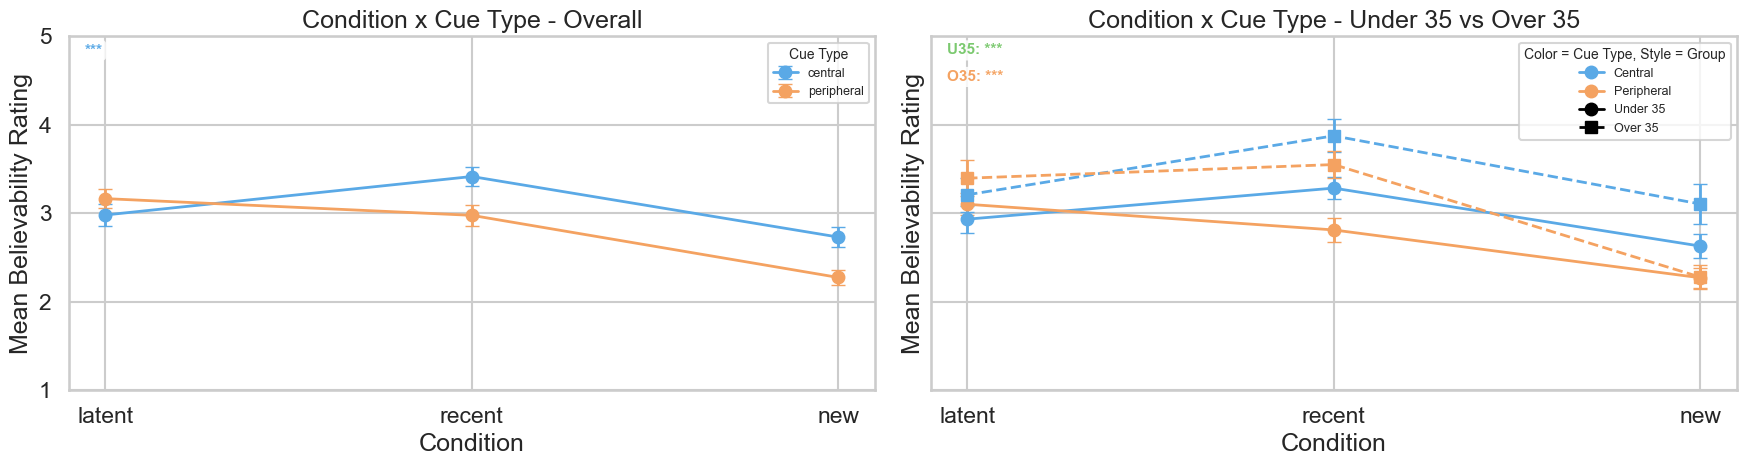

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

s = mean_sem(df_all, ['condition', 'cue_type_final'])
for cue_type in s['cue_type_final'].cat.categories:
    sub = s[s['cue_type_final'] == cue_type]
    axes[0].errorbar(sub['condition'].astype(str), sub['mean'],
                     yerr=sub['sem'], marker='o', linestyle='-',
                     color=CUE_COLORS[str(cue_type)], capsize=5,
                     label=str(cue_type), linewidth=2)

axes[0].set_title('Condition x Cue Type - Overall')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Mean Believability Rating')
axes[0].set_ylim(1, 5)
place_legend(axes[0], title='Cue Type', loc='upper right')
add_sig_badge(axes[0], {'p': anova_p(inferential_results['Overall']['condition_cue_anova']), 'color': COL_OVERALL})

for data, group_label in [(df_u35, 'Under 35'), (df_o35, 'Over 35')]:
    s = mean_sem(data, ['condition', 'cue_type_final'])
    for cue_type in s['cue_type_final'].cat.categories:
        sub = s[s['cue_type_final'] == cue_type]
        style = GROUP_STYLES[group_label]
        axes[1].errorbar(sub['condition'].astype(str), sub['mean'],
                         yerr=sub['sem'], marker=style['marker'], linestyle=style['linestyle'],
                         color=CUE_COLORS[str(cue_type)], capsize=5, linewidth=2)

cue_handles = [Line2D([0], [0], color=color, marker='o', linestyle='-', linewidth=2, label=cue_type.title())
               for cue_type, color in CUE_COLORS.items()]
group_handles = [Line2D([0], [0], color='black', marker=style['marker'], linestyle=style['linestyle'],
                        linewidth=2, label=label)
                 for label, style in GROUP_STYLES.items()]

axes[1].set_title('Condition x Cue Type - Under 35 vs Over 35')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Mean Believability Rating')
axes[1].set_ylim(1, 5)
place_legend(axes[1], handles=cue_handles + group_handles,
             title='Color = Cue Type, Style = Group', loc='upper right')
add_sig_badge(axes[1], [
    {'label': 'U35', 'p': anova_p(inferential_results['Under 35']['condition_cue_anova']), 'color': COL_U35},
    {'label': 'O35', 'p': anova_p(inferential_results['Over 35']['condition_cue_anova']), 'color': COL_O35},
])

plt.tight_layout()
plt.show()


## 9 Boxplots by Factor (Overall plus Under 35 vs Over 35)

**Note**
The top row shows overall distributions, and the bottom row shows under-35 versus over-35 comparisons on the same axes. These panels are descriptive; no direct between-group significance test is added here.

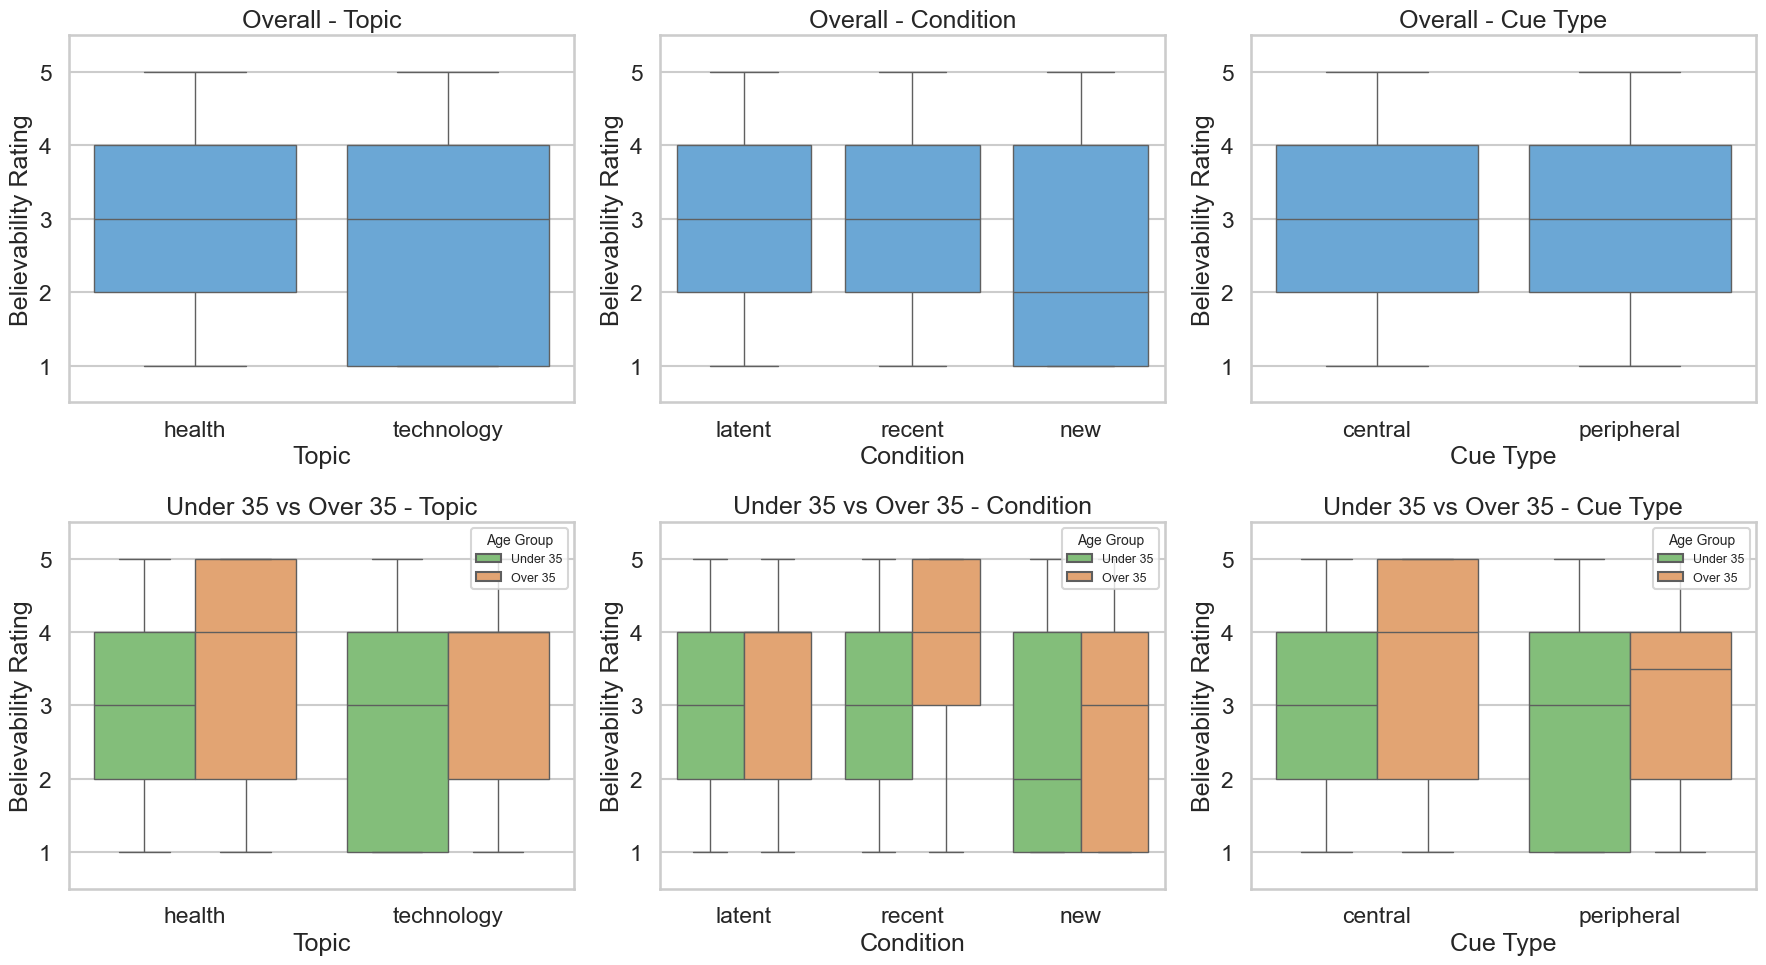

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (factor, title) in enumerate([
    ('topic', 'Topic'),
    ('condition', 'Condition'),
    ('cue_type_final', 'Cue Type'),
]):
    sns.boxplot(data=df_all, x=factor, y='believability_rating',
                color=COL_OVERALL, ax=axes[0, col_idx])
    axes[0, col_idx].set_title(f'Overall - {title}')
    axes[0, col_idx].set_xlabel(title)
    axes[0, col_idx].set_ylabel('Believability Rating')
    axes[0, col_idx].set_ylim(0.5, 5.5)

    sns.boxplot(data=age_comparison, x=factor, y='believability_rating',
                hue='Age Group', palette=AGE_PALETTE, ax=axes[1, col_idx])
    axes[1, col_idx].set_title(f'Under 35 vs Over 35 - {title}')
    axes[1, col_idx].set_xlabel(title)
    axes[1, col_idx].set_ylabel('Believability Rating')
    axes[1, col_idx].set_ylim(0.5, 5.5)
    place_legend(axes[1, col_idx], title='Age Group', loc='upper right')

plt.tight_layout()
plt.show()


## 10 Violin Plots by Factor (Overall plus Under 35 vs Over 35)

**Note**
The top row shows overall distributions, and the bottom row shows under-35 versus over-35 comparisons on the same axes. Inferential results for within-group effects are reported in Sections 2-8 and Section 11.

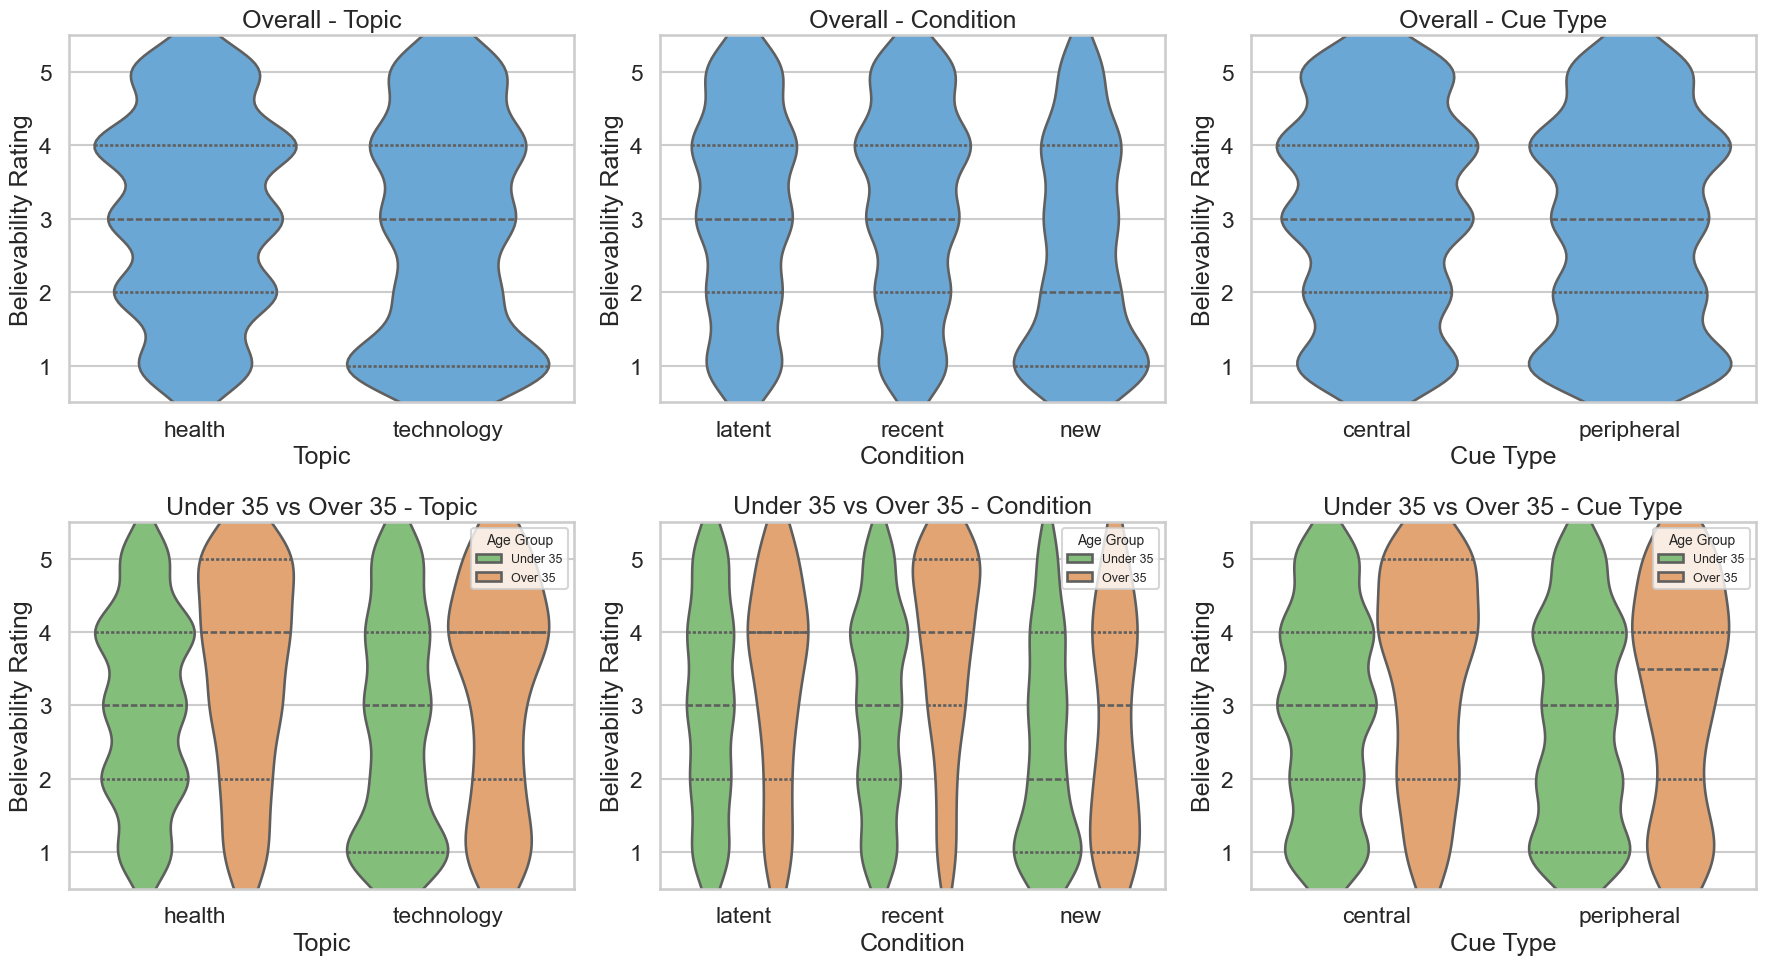

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (factor, title) in enumerate([
    ('topic', 'Topic'),
    ('condition', 'Condition'),
    ('cue_type_final', 'Cue Type'),
]):
    sns.violinplot(data=df_all, x=factor, y='believability_rating',
                   color=COL_OVERALL, inner='quartile', ax=axes[0, col_idx])
    axes[0, col_idx].set_title(f'Overall - {title}')
    axes[0, col_idx].set_xlabel(title)
    axes[0, col_idx].set_ylabel('Believability Rating')
    axes[0, col_idx].set_ylim(0.5, 5.5)

    sns.violinplot(data=age_comparison, x=factor, y='believability_rating',
                   hue='Age Group', palette=AGE_PALETTE, split=False,
                   inner='quartile', ax=axes[1, col_idx])
    axes[1, col_idx].set_title(f'Under 35 vs Over 35 - {title}')
    axes[1, col_idx].set_xlabel(title)
    axes[1, col_idx].set_ylabel('Believability Rating')
    axes[1, col_idx].set_ylim(0.5, 5.5)
    place_legend(axes[1, col_idx], title='Age Group', loc='upper right')

plt.tight_layout()
plt.show()


## 11 Topic x Condition x Cue Type (Three-Way Interaction)

**Significance testing**
A three-factor repeated-measures ANOVA tested the within-participant Topic x Condition x Cue interaction. Bonferroni-corrected central-versus-peripheral comparisons are reported within each topic x condition cell for completeness, with strongest weight given to groups where the omnibus interaction is significant.

**Three-way ANOVA**

| Group | Interaction | df | p | eta_p^2 | Significant |
| --- | --- | --- | --- | --- | --- |
| Overall | F(2, 98) = 3.83 | 2, 98 | p = .025 | 0.073 | Yes |
| Under 35 | F(2, 72) = 0.47 | 2, 72 | p = .626 | 0.013 | No |
| Over 35 | F(2, 22) = 14.06 | 2, 22 | p < .001 | 0.561 | Yes |

**Cue comparisons within each topic x condition cell (Bonferroni-corrected)**

| Group | Topic | Condition | Central mean | Peripheral mean | Test | p (adj) | Significant |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Overall | health | latent | 2.940 | 2.940 | t(49) = 0.00 | p = 1.000 | No |
| Overall | health | recent | 3.740 | 3.353 | t(49) = 3.40 | p = .008 | Yes |
| Overall | health | new | 2.690 | 2.420 | t(49) = 1.70 | p = .570 | No |
| Overall | technology | latent | 3.020 | 3.390 | t(49) = -2.01 | p = .299 | No |
| Overall | technology | recent | 3.090 | 2.410 | t(49) = 5.00 | p < .001 | Yes |
| Overall | technology | new | 2.770 | 2.200 | t(49) = 3.55 | p = .005 | Yes |
| Under 35 | health | latent | 2.824 | 3.027 | t(36) = -1.07 | p = 1.000 | No |
| Under 35 | health | recent | 3.595 | 3.198 | t(36) = 3.04 | p = .026 | Yes |
| Under 35 | health | new | 2.635 | 2.351 | t(36) = 1.52 | p = .820 | No |
| Under 35 | technology | latent | 3.041 | 3.176 | t(36) = -0.67 | p = 1.000 | No |
| Under 35 | technology | recent | 2.973 | 2.230 | t(36) = 4.60 | p < .001 | Yes |
| Under 35 | technology | new | 2.622 | 2.230 | t(36) = 2.12 | p = .246 | No |
| Over 35 | health | latent | 3.292 | 2.750 | t(11) = 2.31 | p = .246 | No |
| Over 35 | health | recent | 4.292 | 3.917 | t(11) = 1.43 | p = 1.000 | No |
| Over 35 | health | new | 2.917 | 2.667 | t(11) = 0.74 | p = 1.000 | No |
| Over 35 | technology | latent | 3.125 | 4.042 | t(11) = -2.49 | p = .181 | No |
| Over 35 | technology | recent | 3.458 | 3.000 | t(11) = 1.69 | p = .717 | No |
| Over 35 | technology | new | 3.292 | 2.083 | t(11) = 4.34 | p = .007 | Yes |

**Interpretation**
The three-way interaction was significant overall and in the over-35 group, but not in the under-35 group. The under-35 cellwise comparisons are therefore best treated as descriptive follow-ups. In the over-35 analysis, the clearest surviving simple effect was the technology-new cell, where central cues were rated much higher than peripheral cues.

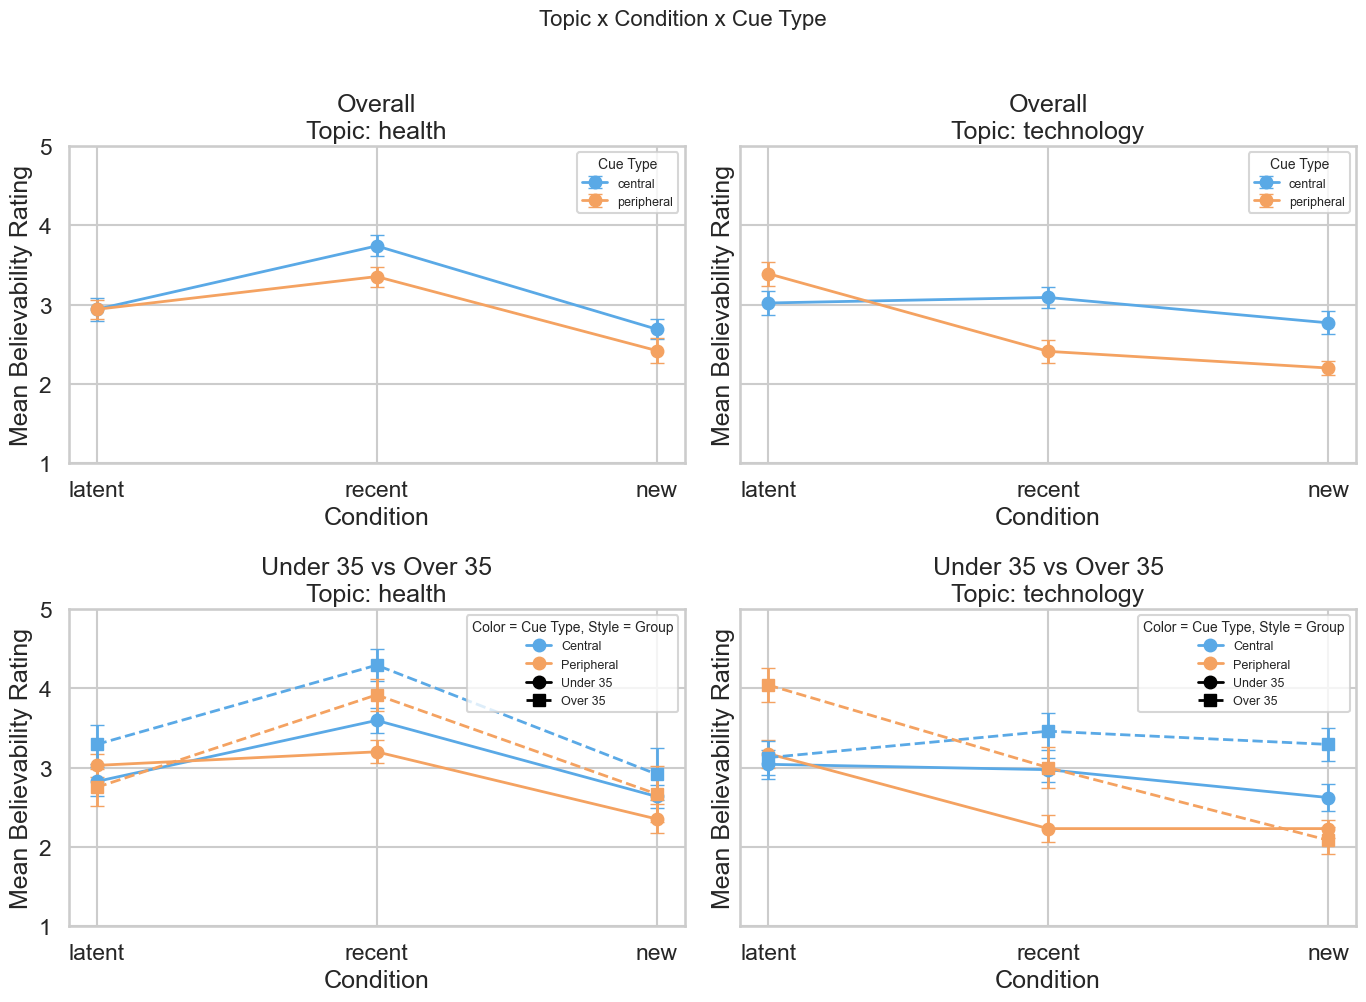

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

topic_levels = list(df_all['topic'].cat.categories)

for col_idx, topic in enumerate(topic_levels):
    overall_sub = df_all[df_all['topic'] == topic]
    s = mean_sem(overall_sub, ['condition', 'cue_type_final'])
    for cue_type in s['cue_type_final'].cat.categories:
        sub = s[s['cue_type_final'] == cue_type]
        axes[0, col_idx].errorbar(sub['condition'].astype(str), sub['mean'],
                                  yerr=sub['sem'], marker='o', linestyle='-',
                                  color=CUE_COLORS[str(cue_type)], capsize=5,
                                  label=str(cue_type), linewidth=2)
    axes[0, col_idx].set_title(f'Overall\nTopic: {topic}')
    axes[0, col_idx].set_xlabel('Condition')
    axes[0, col_idx].set_ylabel('Mean Believability Rating')
    axes[0, col_idx].set_ylim(1, 5)
    place_legend(axes[0, col_idx], title='Cue Type', loc='upper right')

    for data, group_label in [(df_u35, 'Under 35'), (df_o35, 'Over 35')]:
        sub_data = data[data['topic'] == topic]
        s = mean_sem(sub_data, ['condition', 'cue_type_final'])
        style = GROUP_STYLES[group_label]
        for cue_type in s['cue_type_final'].cat.categories:
            sub = s[s['cue_type_final'] == cue_type]
            axes[1, col_idx].errorbar(sub['condition'].astype(str), sub['mean'],
                                      yerr=sub['sem'], marker=style['marker'], linestyle=style['linestyle'],
                                      color=CUE_COLORS[str(cue_type)], capsize=5, linewidth=2)

    cue_handles = [Line2D([0], [0], color=color, marker='o', linestyle='-', linewidth=2, label=cue_type.title())
                   for cue_type, color in CUE_COLORS.items()]
    group_handles = [Line2D([0], [0], color='black', marker=style['marker'], linestyle=style['linestyle'],
                            linewidth=2, label=label)
                     for label, style in GROUP_STYLES.items()]
    axes[1, col_idx].set_title(f'Under 35 vs Over 35\nTopic: {topic}')
    axes[1, col_idx].set_xlabel('Condition')
    axes[1, col_idx].set_ylabel('Mean Believability Rating')
    axes[1, col_idx].set_ylim(1, 5)
    place_legend(axes[1, col_idx], handles=cue_handles + group_handles,
                 title='Color = Cue Type, Style = Group', loc='upper right')

plt.suptitle('Topic x Condition x Cue Type', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## 12 Descriptive Summary Comparison

**Note**
The table below is descriptive and reports the overall sample alongside the two age groups.

In [15]:
def describe_group(data, label):
    return pd.Series({
        'group':                   label,
        'n_participants':          data['Participation Id'].nunique(),
        'n_ratings':               len(data),
        'mean_rating':             data['believability_rating'].mean(),
        'sd_rating':               data['believability_rating'].std(),
        'median_rating':           data['believability_rating'].median(),
        'prop_not_believable_1_2': (data['believability_rating'] <= 2).mean(),
        'prop_neutral_3':          (data['believability_rating'] == 3).mean(),
        'prop_believable_4_5':     (data['believability_rating'] >= 4).mean(),
    })


summary = pd.DataFrame([
    describe_group(df_all, 'Overall'),
    describe_group(df_u35, 'Under 35'),
    describe_group(df_o35, 'Over 35'),
]).set_index('group')

display(summary.round(4))


,n_participants,n_ratings,mean_rating,sd_rating,median_rating,prop_not_believable_1_2,prop_neutral_3,prop_believable_4_5
group,,,,,,,,
Overall,50,1200,2.9525,1.3959,3.0,0.3942,0.2033,0.4025
Under 35,37,888,2.8604,1.3757,3.0,0.4212,0.2083,0.3705
Over 35,12,288,3.2882,1.4205,4.0,0.3090,0.1667,0.5243
